# Label-noise review

Every image in the corpus was predicted by a model that never trained on it (5-fold out-of-fold,
`scripts/make_folds.py` + `scripts/find_label_noise.py`). Below is each suspected swap, most
frequent first, shown as the actual glyphs with the model's confidence above each one.

**What to decide for each pair:** does the picture show the character it is *filed as*, or the one
the *model says*?

- model is right, the label is wrong -> **relabel**
- genuinely ambiguous, or you cannot tell -> **drop** (safer: dropping teaches the model nothing
  wrong, relabelling to match the model's guess makes our own validation score dishonest)
- the label is fine, the model is just weak here -> **keep**

Run All, scroll, then tell Claude your verdicts (or fill in the last cell yourself).


In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
cand = pd.read_csv(ROOT / "reports/analysis/label_noise_candidates.csv")
print(f"candidates: {len(cand):,} images the out-of-fold model disagrees with at >=70% confidence")
print(f"that is {100*len(cand)/59942:.2f}% of the 59,942-image corpus")

pairs = (cand.groupby(["true_char","pred_char"]).size().reset_index(name="n")
             .sort_values("n", ascending=False))
display(pairs.head(20))

candidates: 444 images the out-of-fold model disagrees with at >=70% confidence
that is 0.74% of the 59,942-image corpus


,true_char,pred_char,n
78,า,ๅ,91
73,ั,้,40
88,ๅ,า,31
22,ด,ต,24
17,ช,ซ,18
92,้,ั,14
28,ท,พ,10
34,บ,น,9
18,ซ,ช,8
52,ร,ว,8


In [2]:
# how confident the model is, per pair -- a high mean confidence means the pair is worth trusting
summary = (cand.groupby(["true_char","pred_char"])
               .agg(n=("path","size"), mean_conf=("p_pred","mean"), mean_margin=("margin","mean"))
               .reset_index().sort_values("n", ascending=False))
summary["suggest"] = ["relabel" if (r.mean_conf > 0.85 and r.n >= 5) else "look closely"
                      for r in summary.itertuples()]
display(summary.head(20).style.format({"mean_conf":"{:.3f}","mean_margin":"{:.3f}"}))

,true_char,pred_char,n,mean_conf,mean_margin,suggest
78,า,ๅ,91,0.799,0.688,look closely
73,ั,้,40,0.840,0.765,look closely
88,ๅ,า,31,0.792,0.680,look closely
22,ด,ต,24,0.880,0.860,relabel
17,ช,ซ,18,0.831,0.745,look closely
92,้,ั,14,0.874,0.845,relabel
28,ท,พ,10,0.806,0.711,look closely
34,บ,น,9,0.896,0.888,relabel
18,ซ,ช,8,0.814,0.717,look closely
52,ร,ว,8,0.837,0.778,look closely


## filed as **า** — model says **ๅ** &nbsp;&nbsp; (91 images, mean confidence 0.80)

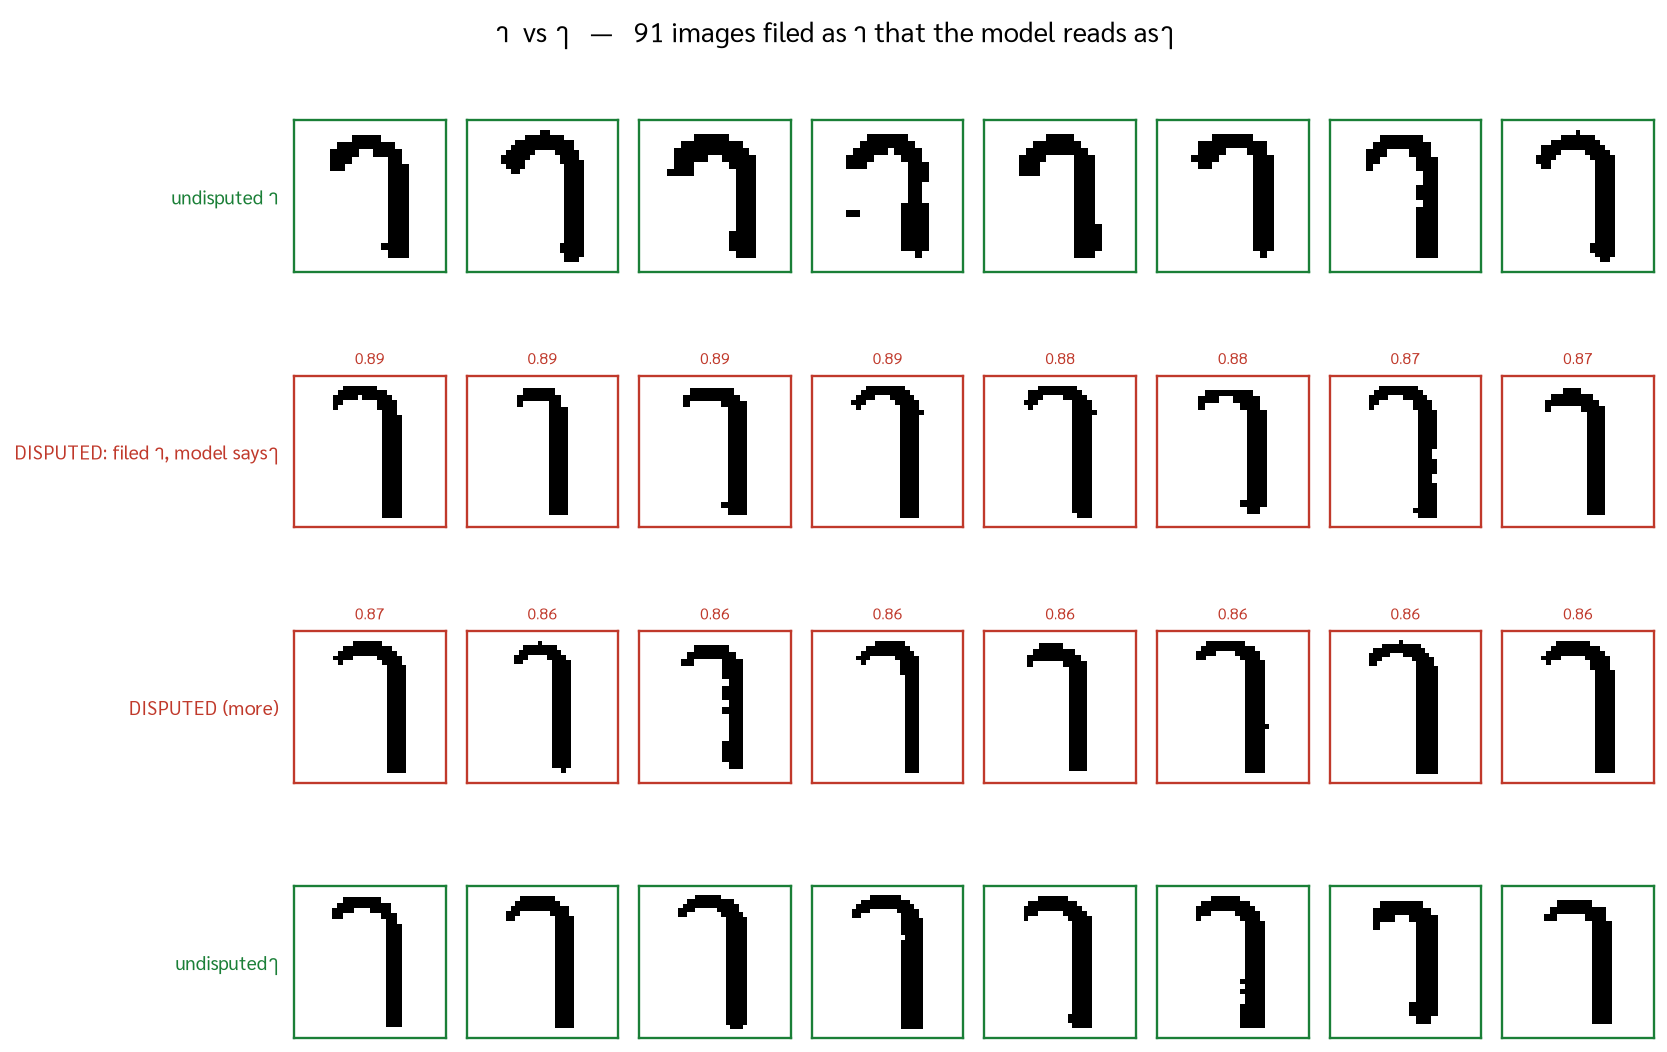

## filed as **ั** — model says **้** &nbsp;&nbsp; (40 images, mean confidence 0.84)

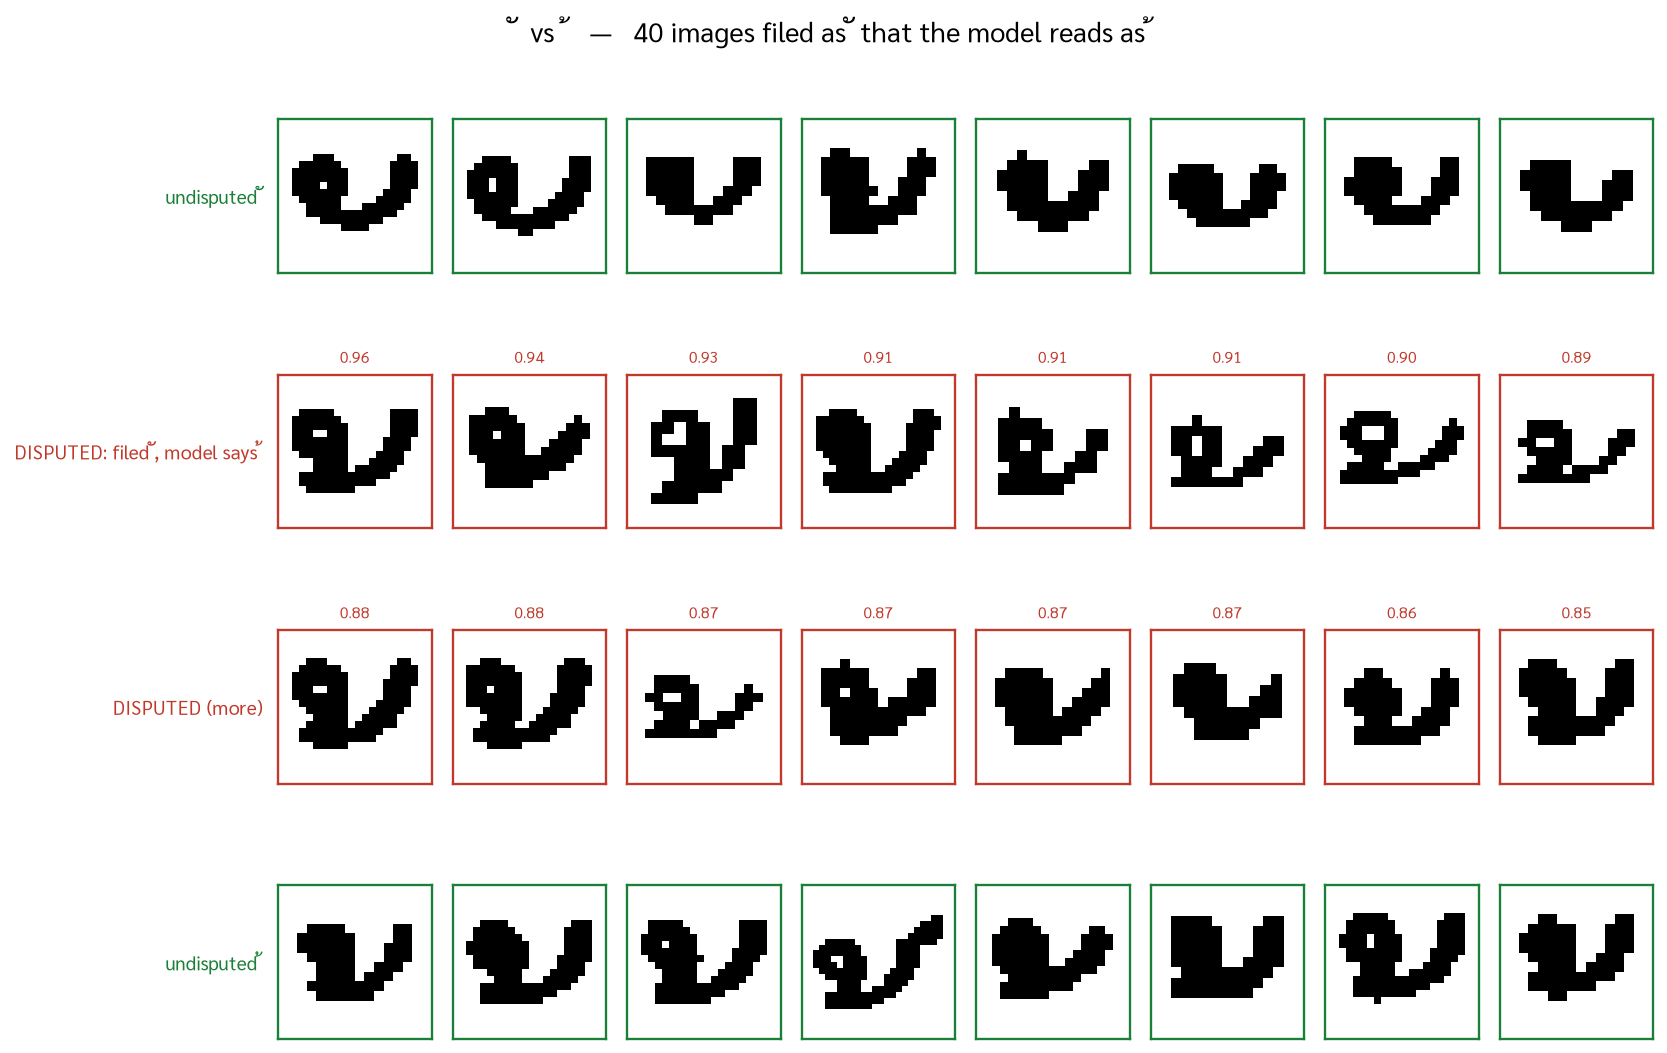

## filed as **ๅ** — model says **า** &nbsp;&nbsp; (31 images, mean confidence 0.79)

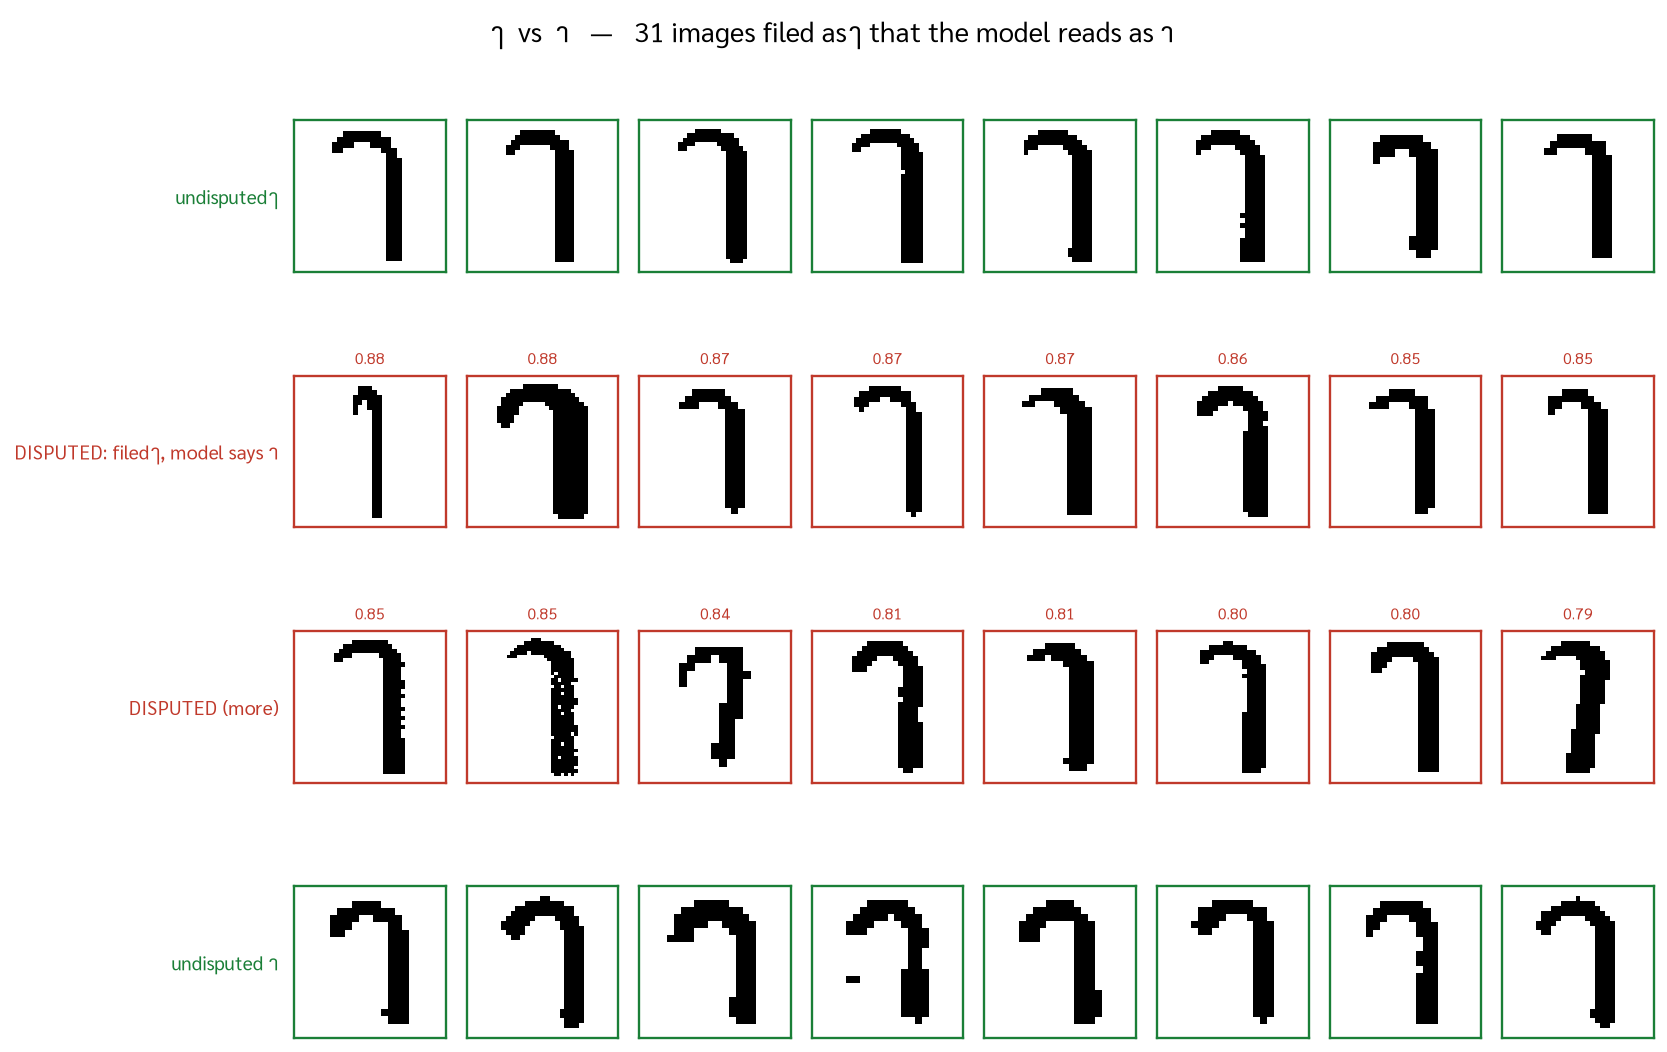

## filed as **ด** — model says **ต** &nbsp;&nbsp; (24 images, mean confidence 0.88)

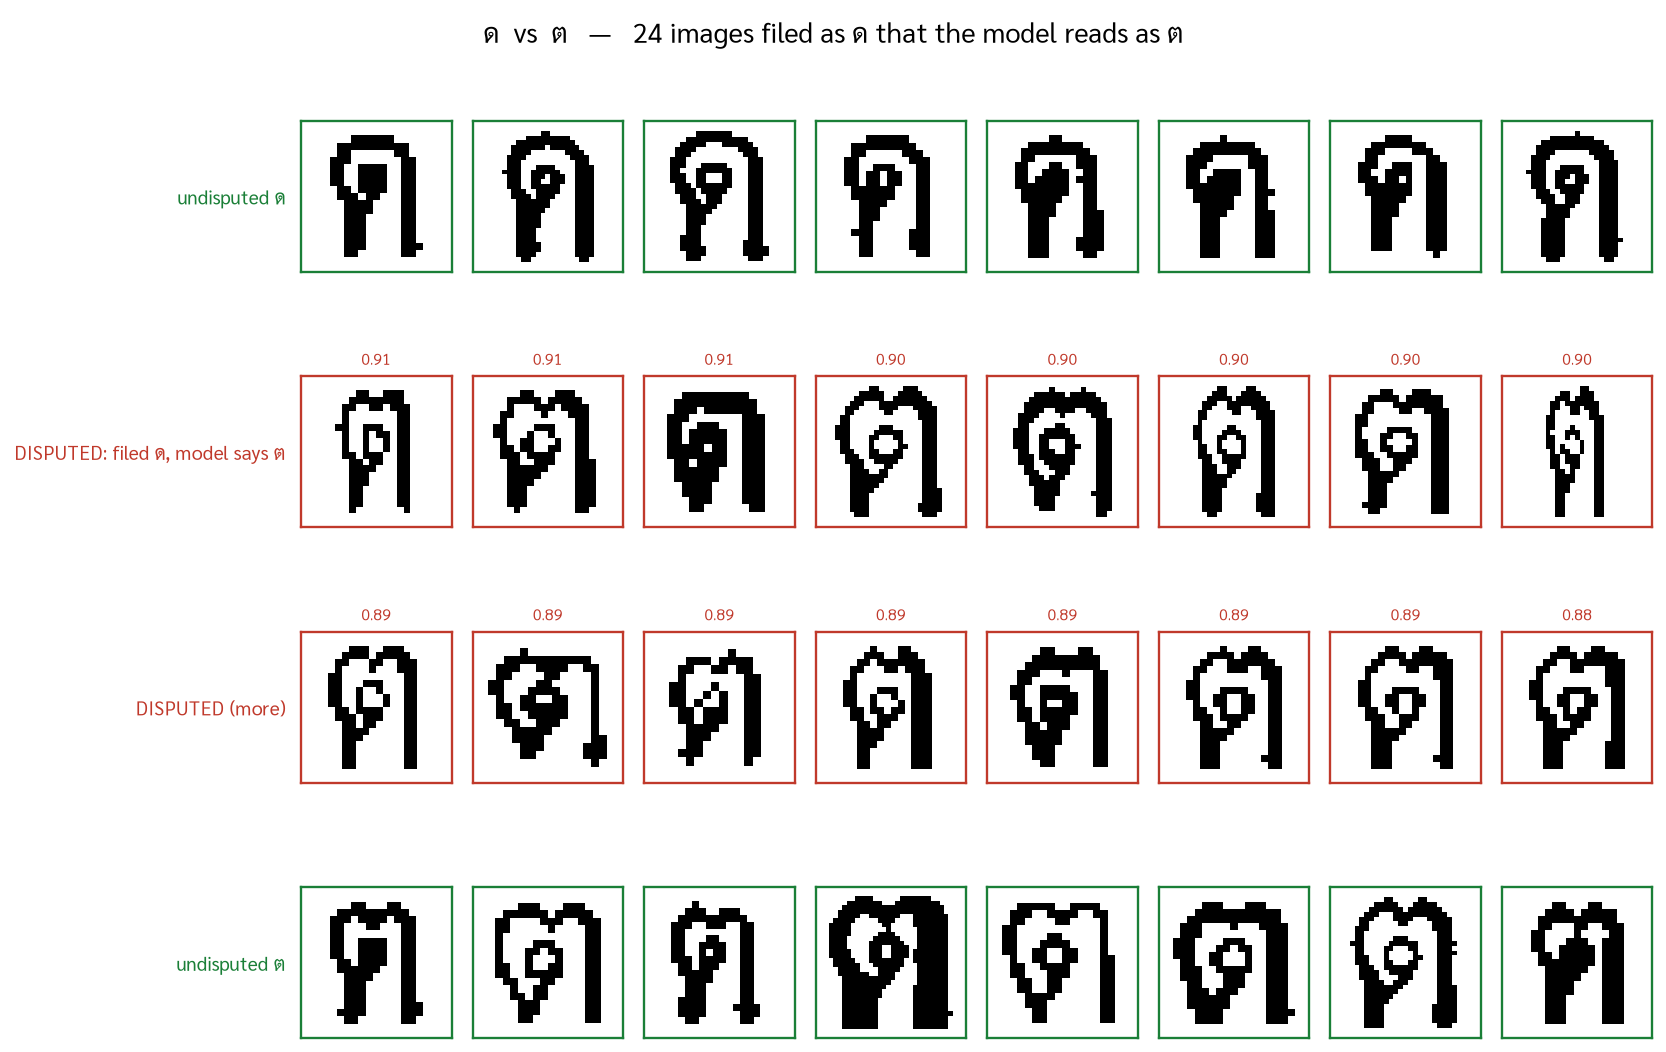

## filed as **ช** — model says **ซ** &nbsp;&nbsp; (18 images, mean confidence 0.83)

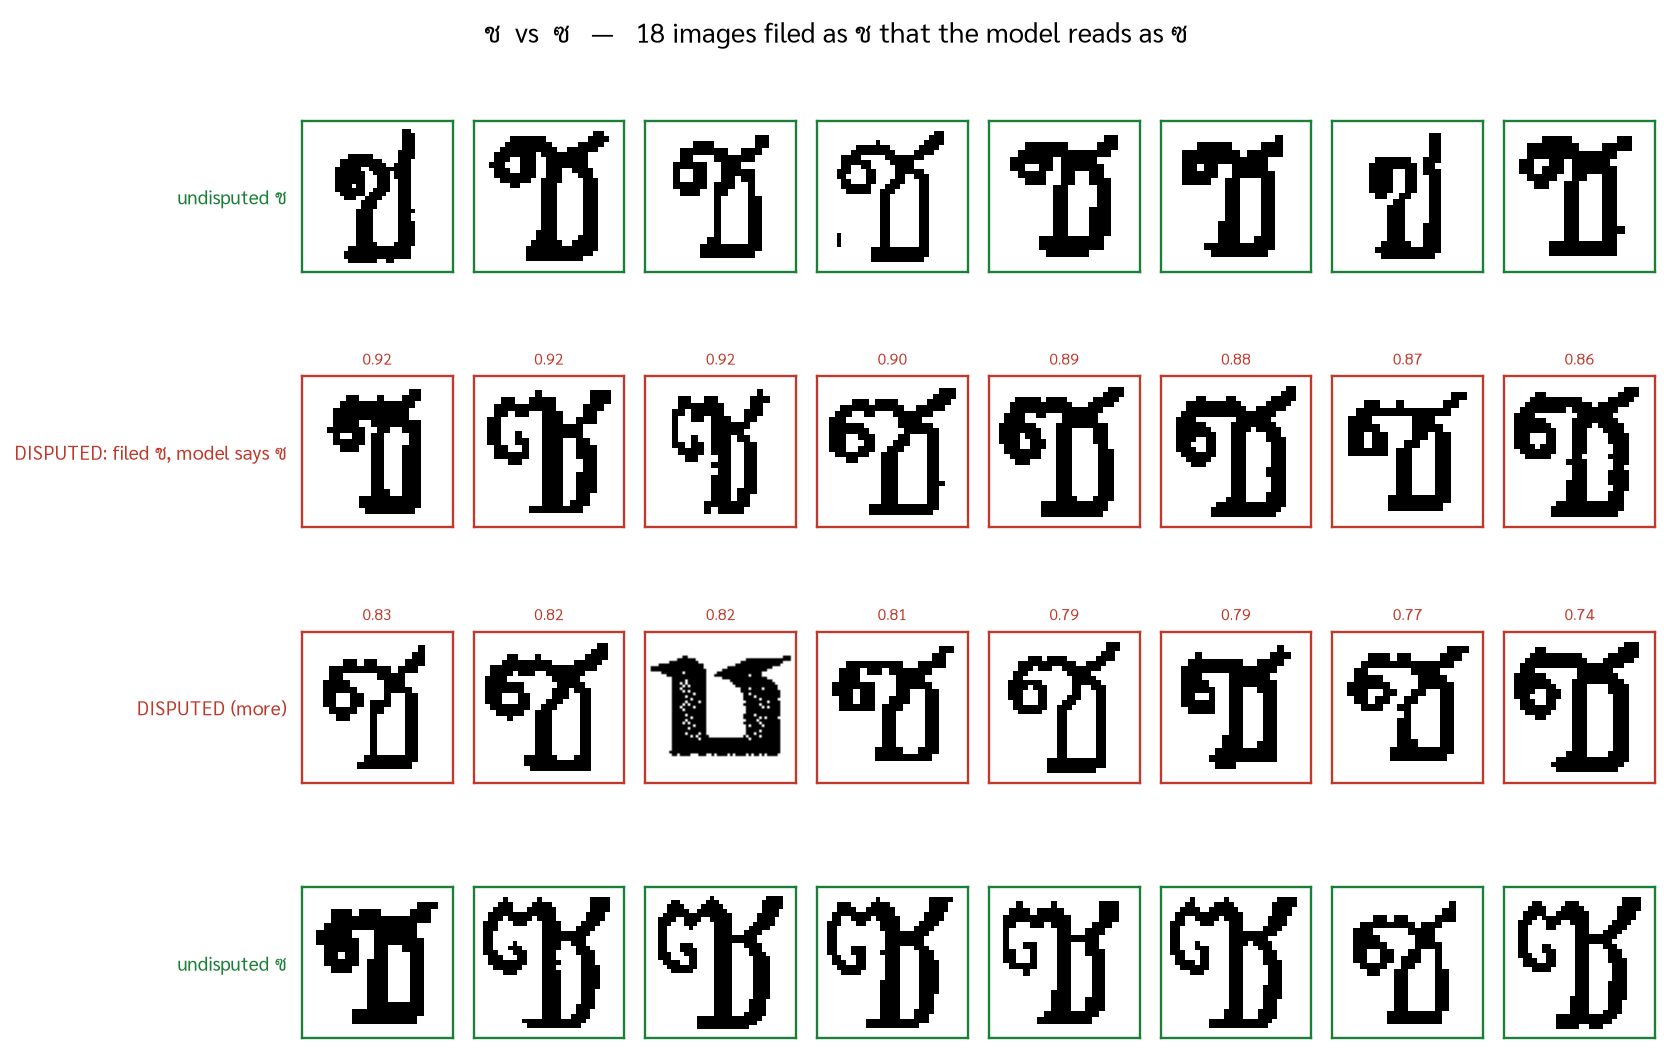

## filed as **้** — model says **ั** &nbsp;&nbsp; (14 images, mean confidence 0.87)

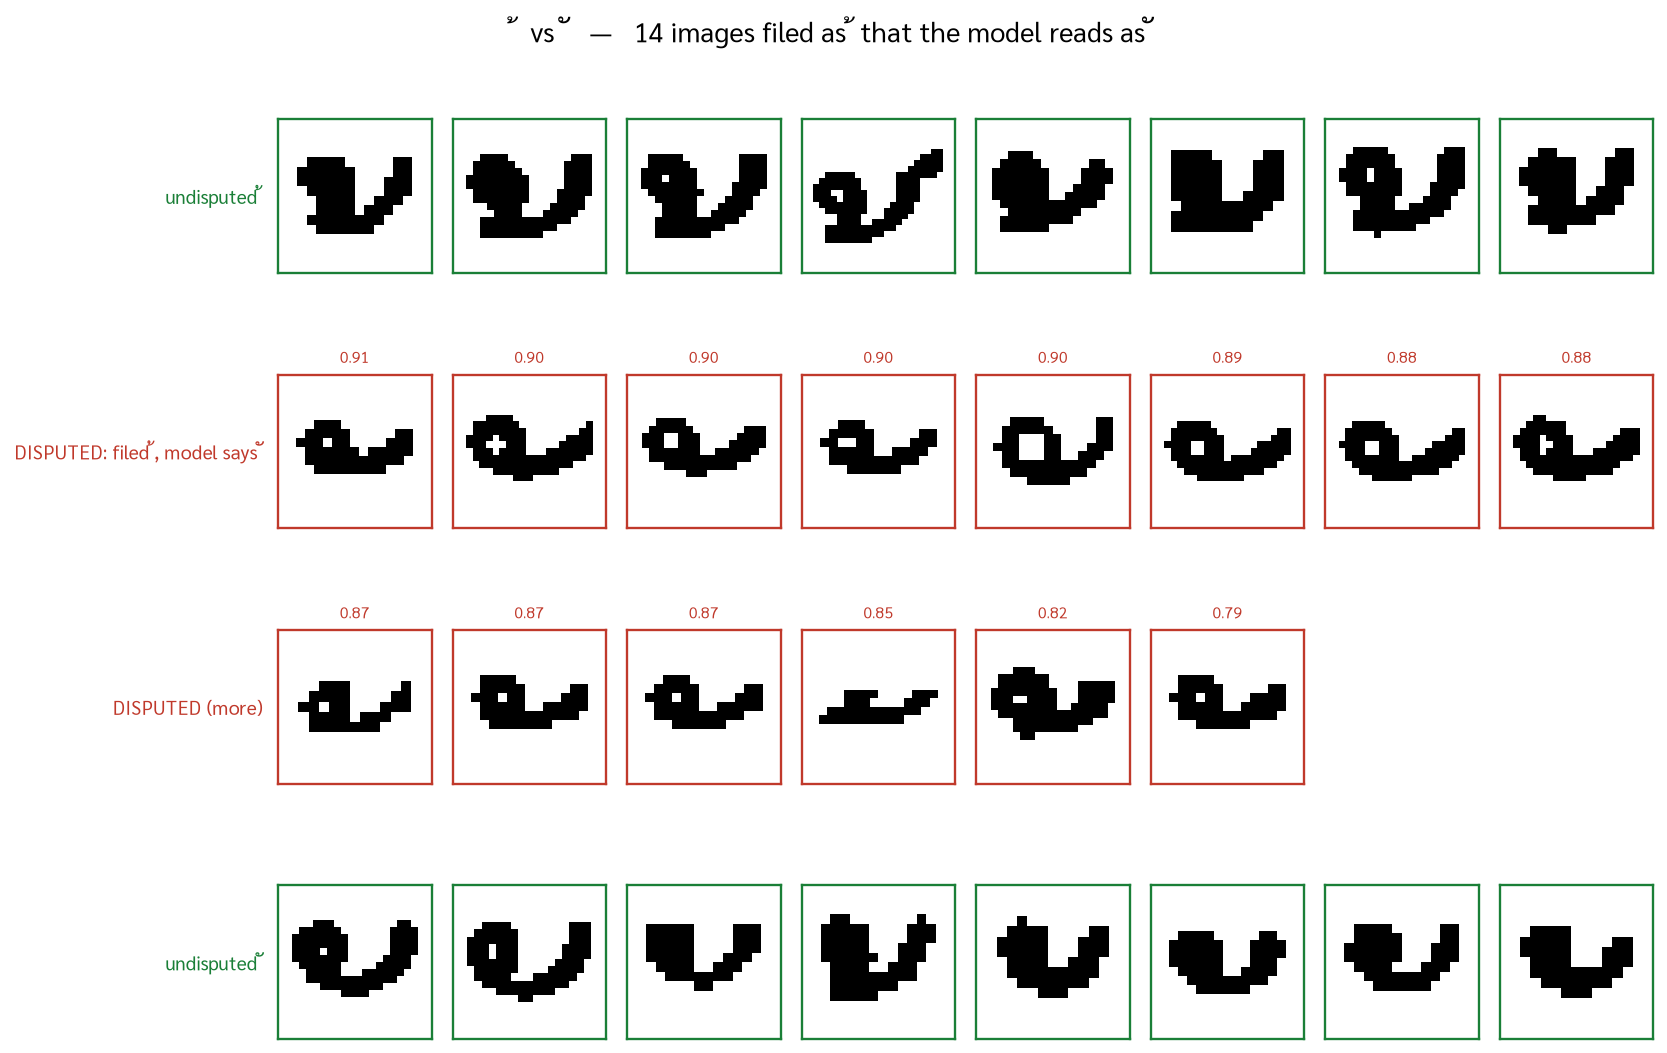

## filed as **ท** — model says **พ** &nbsp;&nbsp; (10 images, mean confidence 0.81)

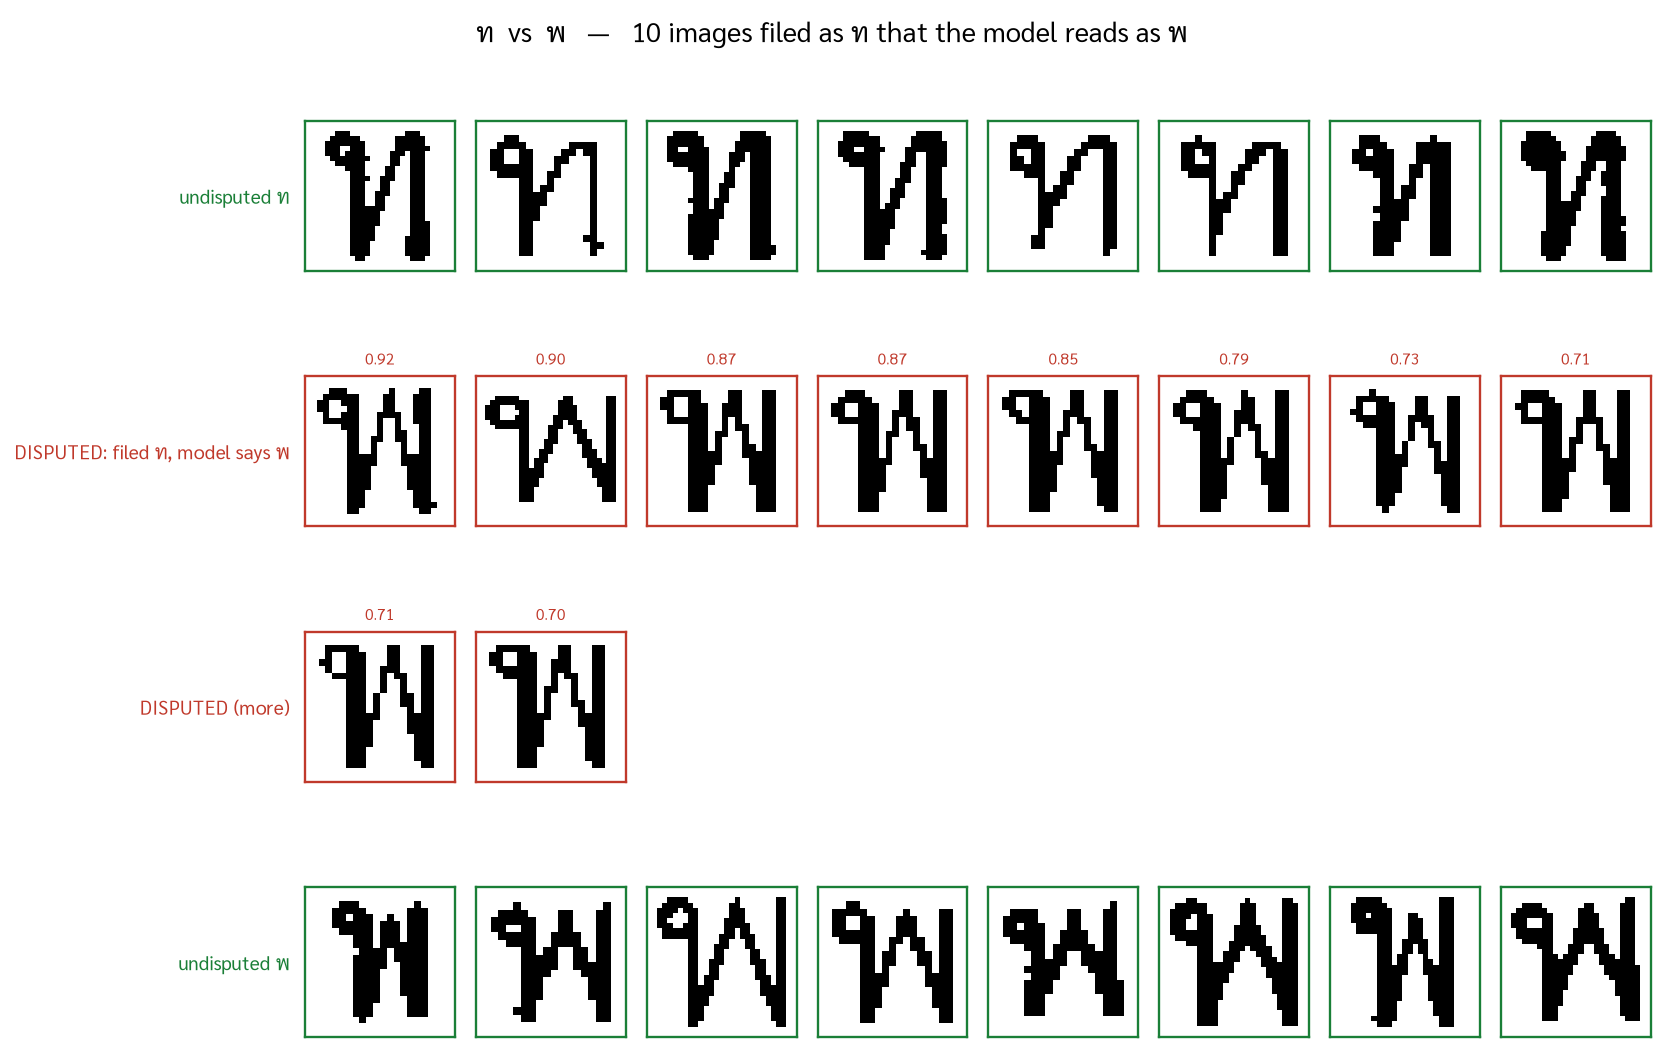

## filed as **บ** — model says **น** &nbsp;&nbsp; (9 images, mean confidence 0.90)

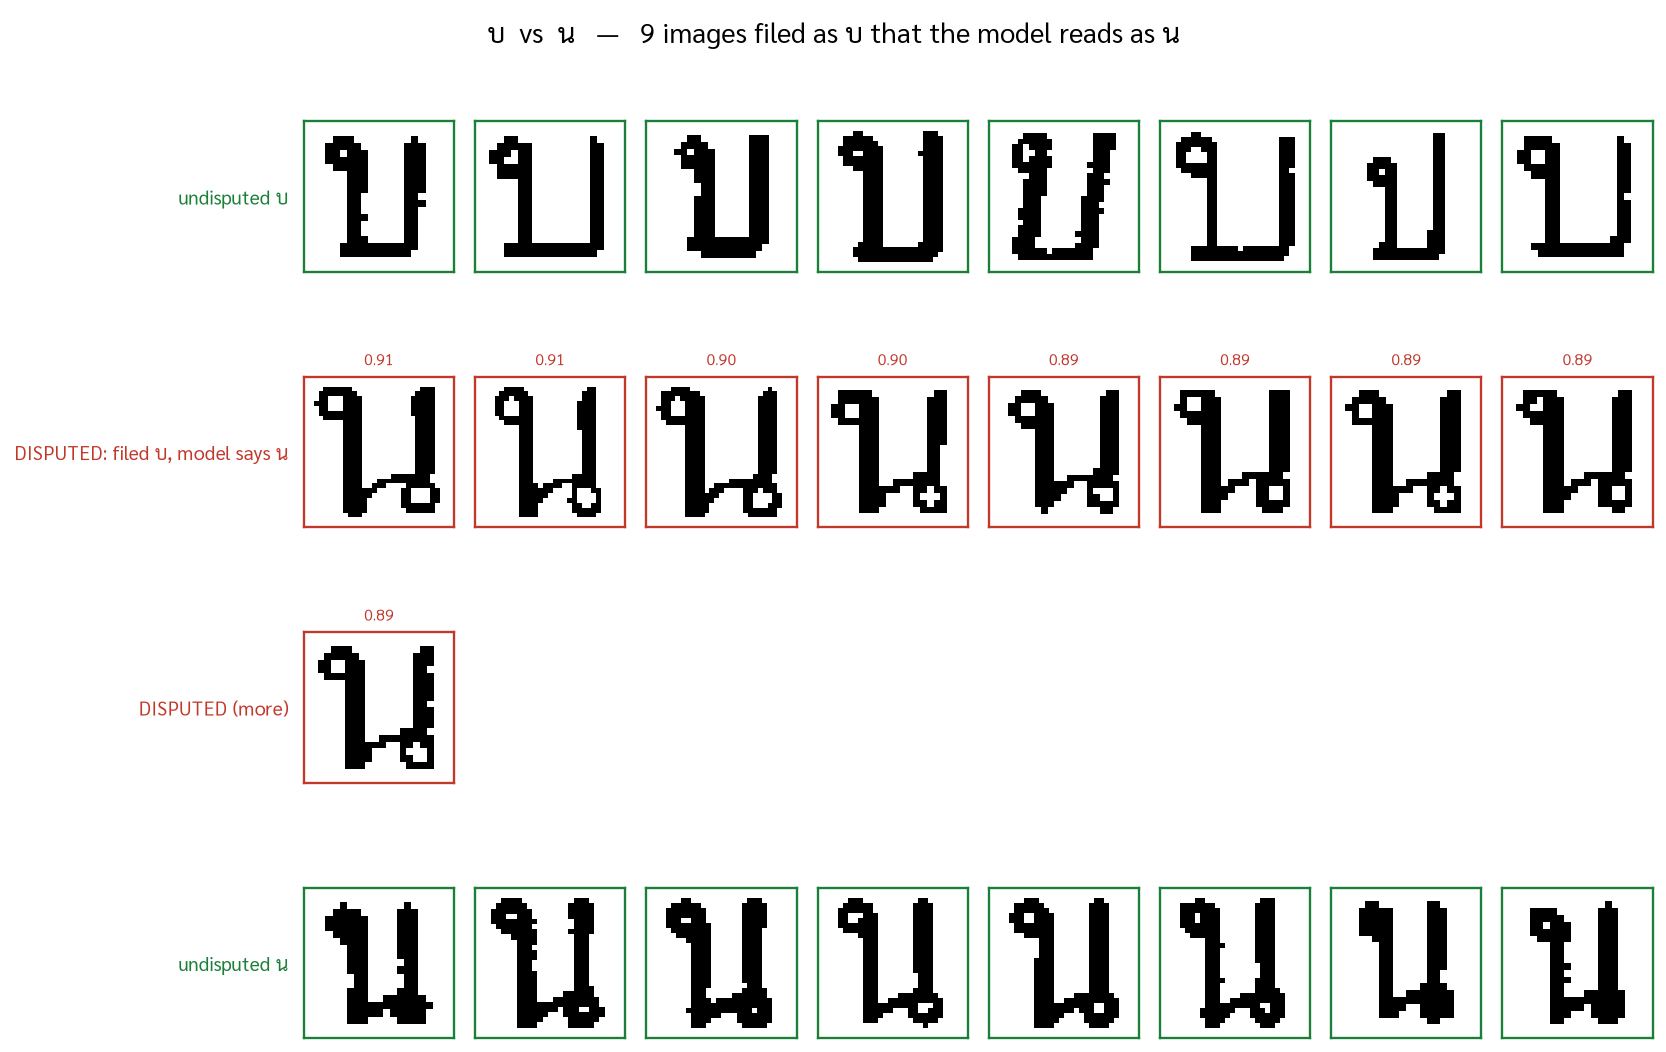

## filed as **ซ** — model says **ช** &nbsp;&nbsp; (8 images, mean confidence 0.81)

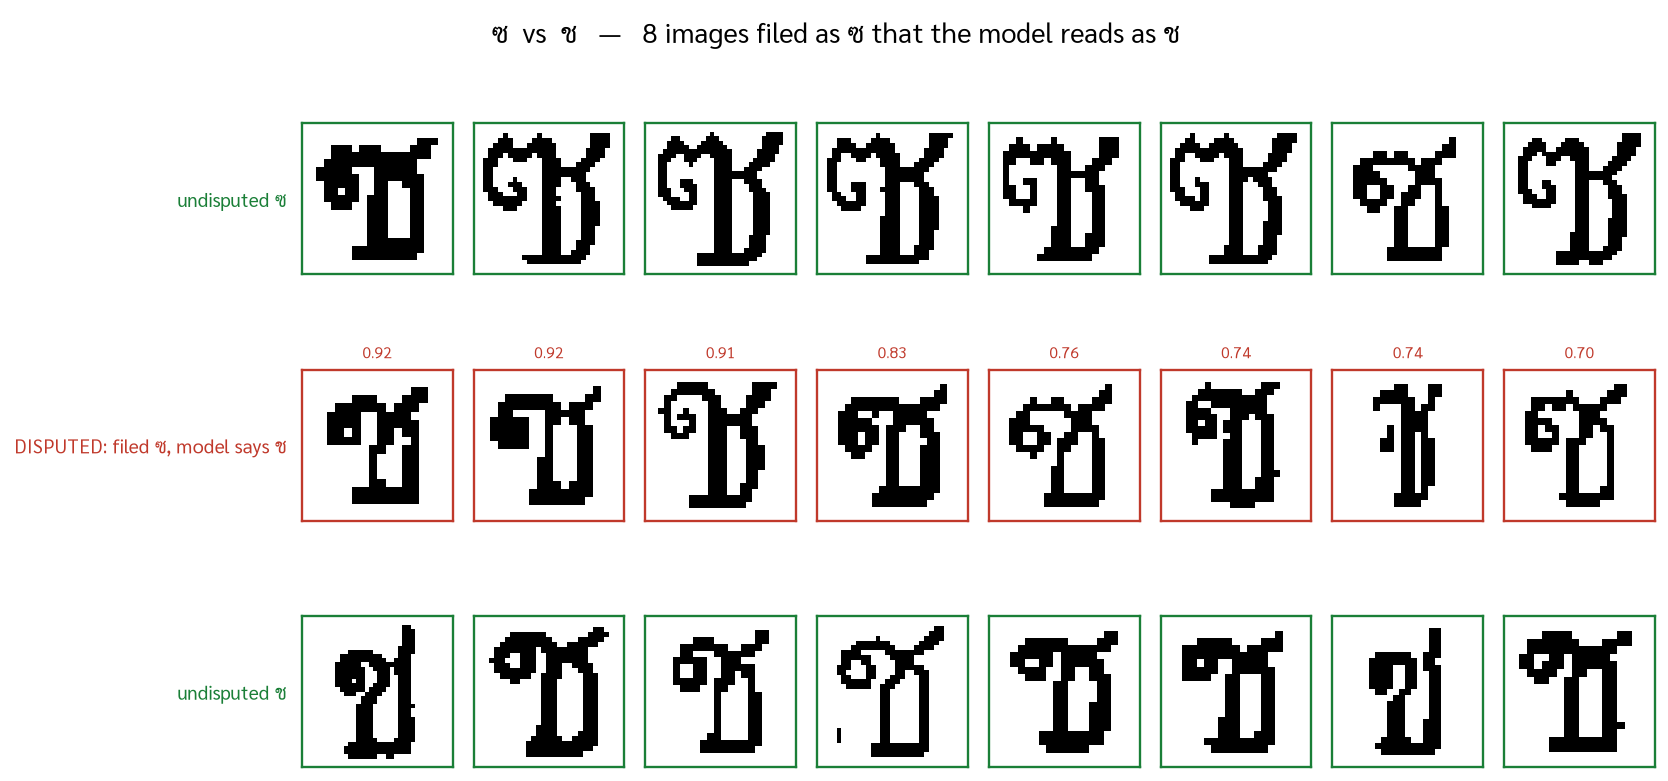

## filed as **ร** — model says **ว** &nbsp;&nbsp; (8 images, mean confidence 0.84)

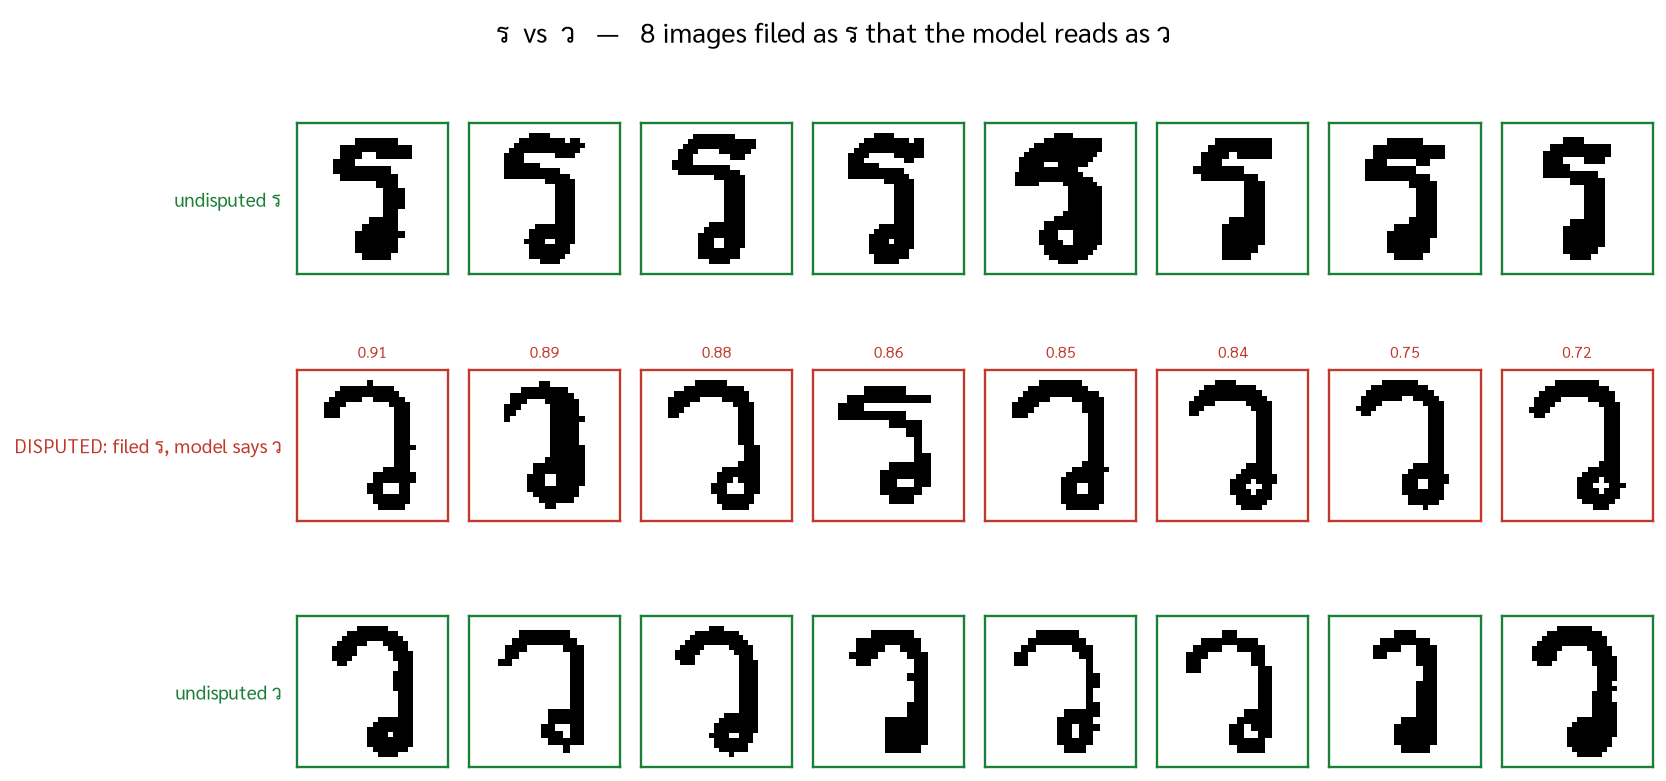

## filed as **ว** — model says **ร** &nbsp;&nbsp; (8 images, mean confidence 0.86)

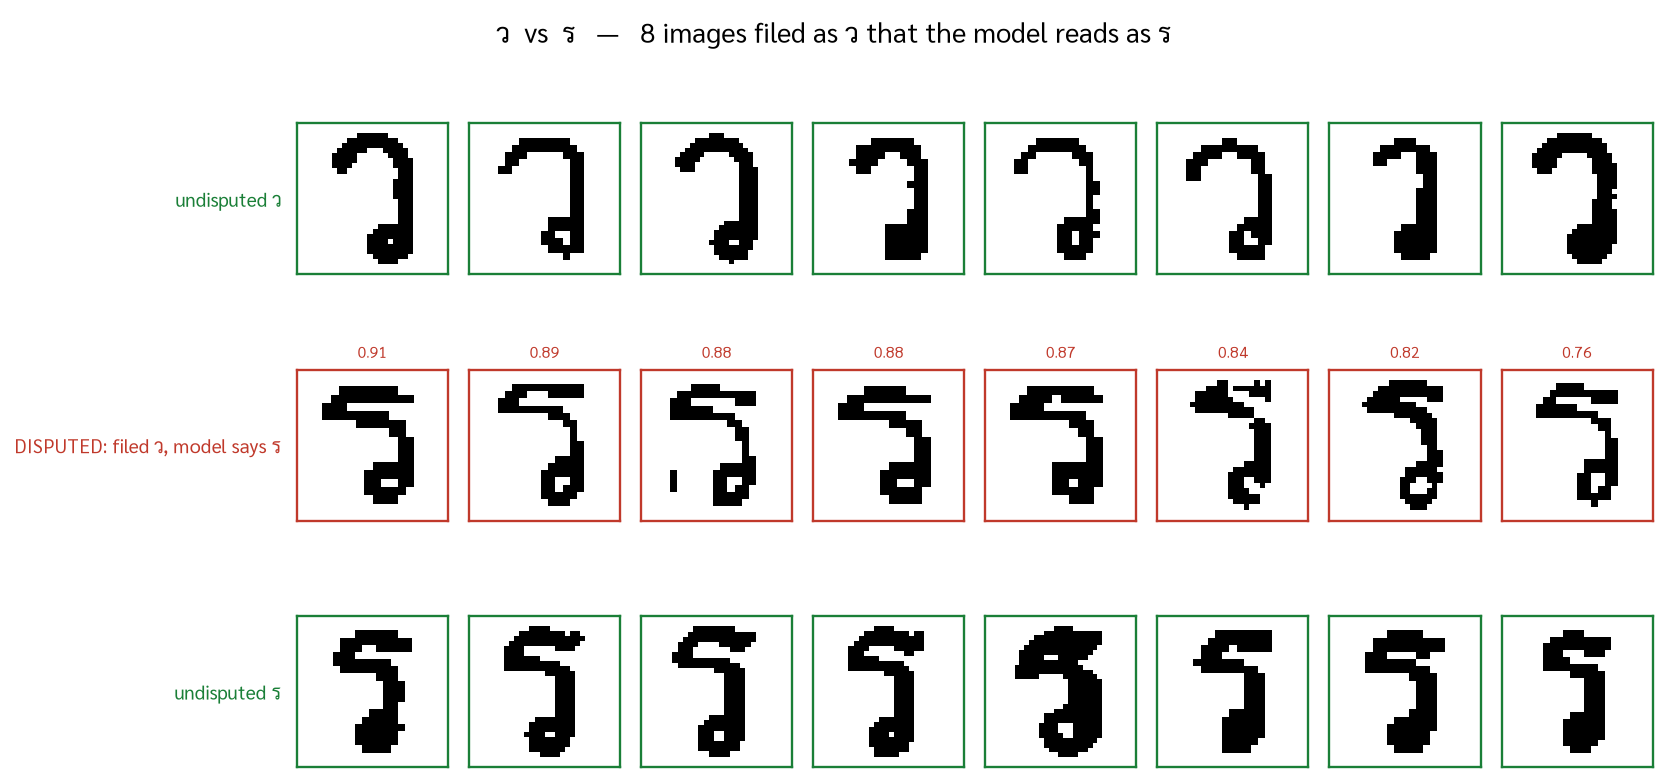

## filed as **น** — model says **ม** &nbsp;&nbsp; (7 images, mean confidence 0.89)

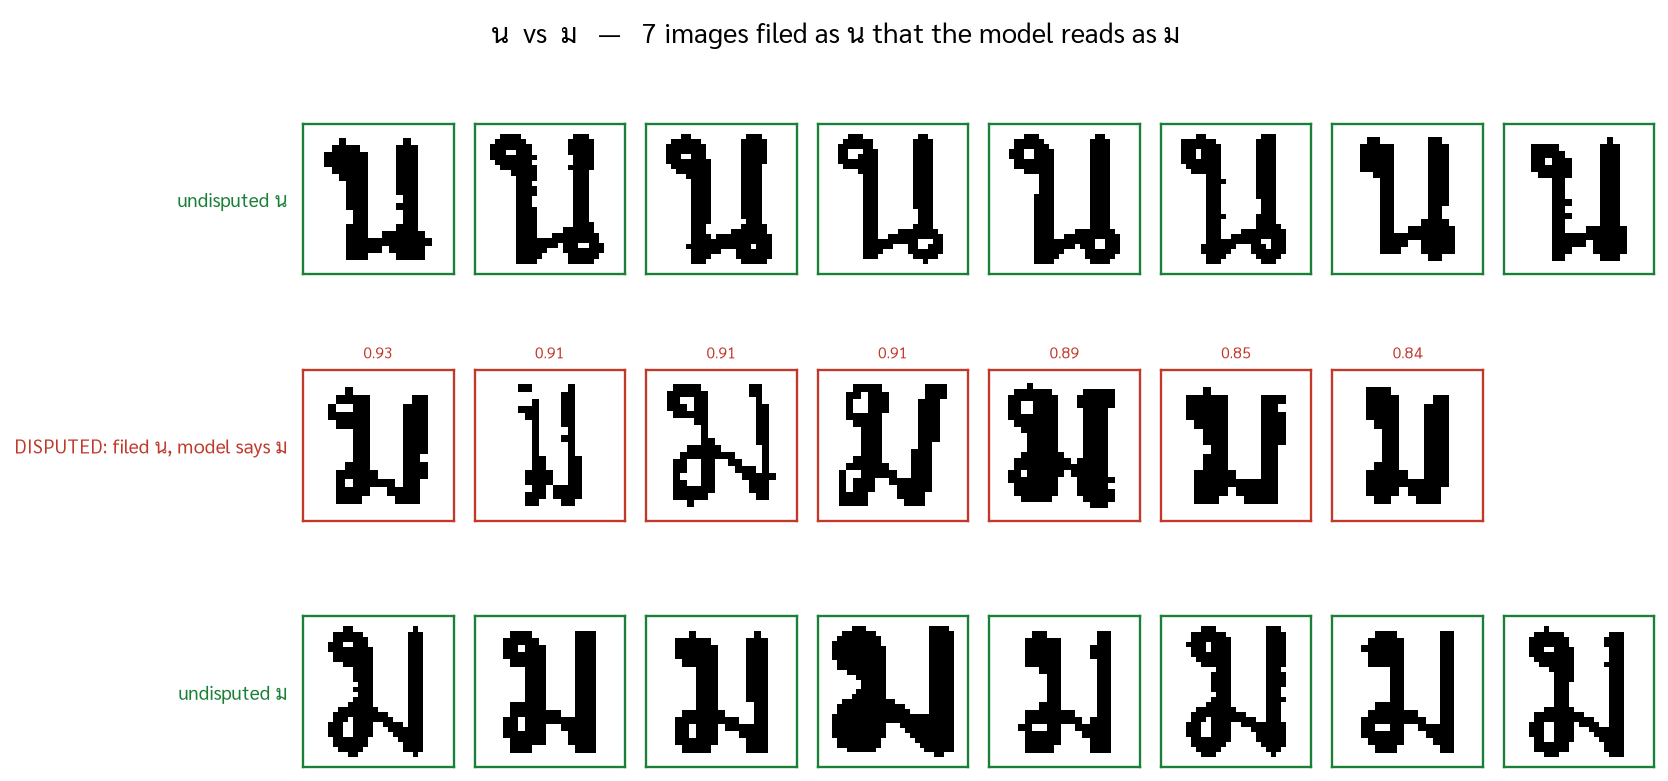

## filed as **ค** — model says **ด** &nbsp;&nbsp; (7 images, mean confidence 0.87)

## filed as **ด** — model says **ค** &nbsp;&nbsp; (7 images, mean confidence 0.87)

## filed as **๘** — model says **็** &nbsp;&nbsp; (7 images, mean confidence 0.85)

## filed as **ล** — model says **ส** &nbsp;&nbsp; (6 images, mean confidence 0.84)

## filed as **า** — model says **ใ** &nbsp;&nbsp; (5 images, mean confidence 0.85)

...

## filed as **ุ** — model says **่** &nbsp;&nbsp; (1 images, mean confidence 0.85)

## filed as **็** — model says **ี** &nbsp;&nbsp; (1 images, mean confidence 0.90)

## filed as **ๆ** — model says **า** &nbsp;&nbsp; (1 images, mean confidence 0.84)

## filed as **่** — model says **เ** &nbsp;&nbsp; (1 images, mean confidence 0.78)

## filed as **้** — model says **่** &nbsp;&nbsp; (1 images, mean confidence 0.82)

In [3]:
MONT = ROOT / "reports/analysis/label_noise"
for r in pairs.itertuples():
    s = summary[(summary.true_char==r.true_char) & (summary.pred_char==r.pred_char)].iloc[0]
    display(Markdown(f"## filed as **{r.true_char}** — model says **{r.pred_char}** &nbsp;&nbsp; "
                     f"({r.n} images, mean confidence {s.mean_conf:.2f})"))
    # side-by-side sheet: undisputed examples of BOTH classes around the disputed ones,
    # so the distinguishing stroke is visible instead of remembered
    cmp_f = MONT / f"compare_{r.true_char}_vs_{r.pred_char}.png"
    if cmp_f.exists():
        display(Image(filename=str(cmp_f)))
    else:
        f = MONT / f"{r.true_char}_to_{r.pred_char}.png"
        if f.exists():
            display(Image(filename=str(f)))


---

## Record your verdicts

Edit the dict below, then run the cell. It prints the exact command to apply them.
Anything you leave out is left untouched.


In [4]:
VERDICTS = {
    # "filed>model": "relabel" | "drop"
    # e.g.  "ช>ซ": "relabel",
    #       "า>ๅ": "drop",
}

rel = [k for k, v in VERDICTS.items() if v == "relabel"]
drp = [k for k, v in VERDICTS.items() if v == "drop"]
if not rel and not drp:
    print("nothing chosen yet -- fill in VERDICTS above")
else:
    n = sum(int(pairs[(pairs.true_char==k.split(">")[0]) & (pairs.pred_char==k.split(">")[1])].n.iloc[0])
            for k in rel + drp)
    cmd = "uv run --no-sync python scripts/apply_label_fixes.py"
    if rel: cmd += " --relabel " + " ".join(f'"{k}"' for k in rel)
    if drp: cmd += " --drop " + " ".join(f'"{k}"' for k in drp)
    cmd += " --out data/splits/split_seed42_v3.csv"
    print(f"{n} image(s) affected\n")
    print(cmd)

nothing chosen yet -- fill in VERDICTS above
